# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

## Load Data

In [2]:
df = pd.read_csv('data/df_ready.csv')

In [3]:
df.head()

,Unnamed: 0,Date_imp,Date_imp_d,Cluster,Category_name,name,price,disc_price,merchant,condition,...,sourceURLs,weight,Date_imp_d.1,Day_n,month,month_n,day,Week_Number,Zscore_1,price_std
0,4,2017-12-14 06:00:00,2017/12/14,35,"speaker, portable, bluetooth",Boytone - 2500W 2.1-Ch. Home Theater System - ...,69.00,64.99,Walmart.com,New,...,https://www.walmart.com/ip/BOYTONE-BT210FB-BLA...,14 pounds,2017/12/14,Thursday,12,December,14,50,0.001525,3.880725
1,5,2017-09-08 05:00:00,2017/09/08,35,"speaker, portable, bluetooth",Boytone - 2500W 2.1-Ch. Home Theater System - ...,69.00,69.00,Walmart.com,New,...,https://www.walmart.com/ip/Boytone-BT-210F-Blu...,14 pounds,2017/09/08,Friday,9,September,8,36,0.001525,3.880725
2,6,2017-10-24 04:00:00,2017/10/24,35,"speaker, portable, bluetooth",Boytone - 2500W 2.1-Ch. Home Theater System - ...,66.00,66.00,Walmart.com,New,...,https://www.walmart.com/ip/Boytone-BT-210F-Blu...,14 pounds,2017/10/24,Tuesday,10,October,24,43,-0.760844,3.880725
3,7,2017-08-15 15:00:00,2017/08/15,35,"speaker, portable, bluetooth",Boytone - 2500W 2.1-Ch. Home Theater System - ...,74.99,74.99,Walmart.com,New,...,https://www.walmart.com/ip/Boytone-BT-210F-Blu...,14 pounds,2017/08/15,Tuesday,8,August,15,33,1.523722,3.880725
4,8,2017-09-14 21:00:00,2017/09/14,35,"speaker, portable, bluetooth",Boytone - 2500W 2.1-Ch. Home Theater System - ...,69.99,69.99,Walmart.com,New,...,https://www.walmart.com/ip/Boytone-BT-210F-Blu...,14 pounds,2017/09/14,Thursday,9,September,14,37,0.253107,3.880725


# Seleção para realizar a elasticidade

## Qual loja vendeu mais?

<AxesSubplot:xlabel='merchant', ylabel='Date_imp'>

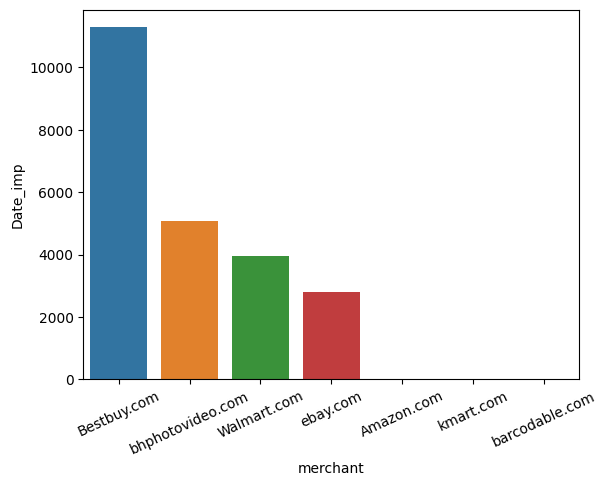

In [4]:
aux1 = df[['Date_imp', 'merchant']].groupby('merchant').count().sort_values(by='Date_imp', ascending=False).reset_index()
plt.xticks(rotation =25)
sns.barplot(data=aux1, x="merchant", y="Date_imp")

In [5]:
#seleção da loja que realizou mais vendas
df_best = df[df['merchant']=='Bestbuy.com']

### Categoria mais vendida na Bestbuy

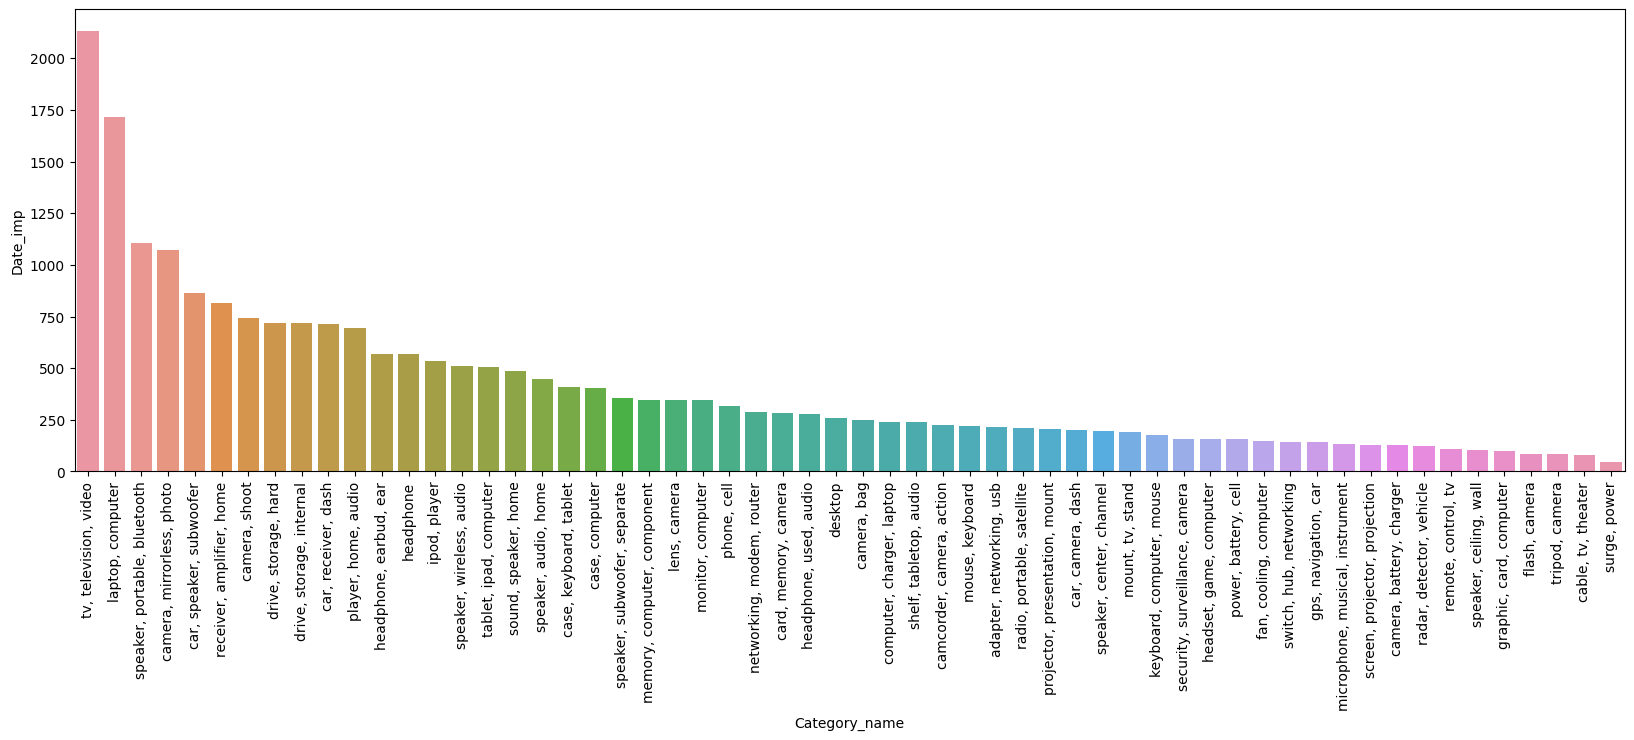

In [6]:
aux2 = df[['Date_imp', 'Category_name']].groupby('Category_name').count().sort_values(by='Date_imp', ascending=False).reset_index()
#aux2
plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
sns.barplot(data=aux2, x="Category_name", y="Date_imp");

#### tv, television, video

In [7]:
#seleção da categoria que realizou mais vendas
df_tv = df_best[df_best['Category_name']=='tv, television, video']

In [8]:
#checando os NAs
df_tv.isna().sum()

Unnamed: 0           0
Date_imp             0
Date_imp_d           0
Cluster              0
Category_name        0
name                 0
price                0
disc_price           0
merchant             0
condition            0
Disc_percentage      0
isSale               0
Imp_count            0
brand                0
p_description        0
currency             0
dateAdded            0
dateSeen             0
dateUpdated          0
imageURLs          379
manufacturer       274
shipping           185
sourceURLs          18
weight               0
Date_imp_d.1         0
Day_n                0
month                0
month_n              0
day                  0
Week_Number          0
Zscore_1             0
price_std            0
dtype: int64

In [9]:
#vendas por semana
test1 = df_tv.groupby(['name', 'Week_Number']).agg({'disc_price': 'mean' ,'Date_imp': 'count' }).reset_index()
test1

,name,Week_Number,disc_price,Date_imp
0,Details About Openbox Excellent: Lg 32 Class (...,19,219.99,1
1,Details About Openbox Excellent: Lg 32 Class (...,20,219.99,1
2,Details About Openbox Excellent: Lg 32 Class (...,22,208.49,4
3,Details About Openbox Excellent: Lg 32 Class (...,26,208.49,2
4,Details About Openbox Excellent: Lg 32 Class (...,30,189.49,2
...,...,...,...,...
212,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,20,2999.99,1
213,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,22,2999.99,2
214,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,27,2575.99,1
215,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,30,2879.99,2


#### laptop, computer

In [10]:
#seleção da categoria que realizou mais vendas
df_laptop = df_best[df_best['Category_name']=='laptop, computer']

In [11]:
#checando os NAs
df_laptop.isna().sum()

Unnamed: 0            0
Date_imp              0
Date_imp_d            0
Cluster               0
Category_name         0
name                  0
price                 0
disc_price            0
merchant              0
condition             0
Disc_percentage       0
isSale                0
Imp_count             0
brand                 0
p_description         0
currency              0
dateAdded             0
dateSeen              0
dateUpdated           0
imageURLs          1061
manufacturer        627
shipping           1068
sourceURLs          359
weight                0
Date_imp_d.1          0
Day_n                 0
month                 0
month_n               0
day                   0
Week_Number           0
Zscore_1              0
price_std             0
dtype: int64

In [12]:
#vendas por semana
test2 = df_laptop.groupby(['name', 'Week_Number']).agg({'disc_price': 'mean' ,'Date_imp': 'count' }).reset_index()
test2

,name,Week_Number,disc_price,Date_imp
0,"12 MacBook (Mid 2017, Gold)",30,1599.99,1
1,"12 MacBook (Mid 2017, Gold)",31,1551.99,8
2,"12 MacBook (Mid 2017, Gold)",33,1454.99,2
3,"12 MacBook (Mid 2017, Gold)",34,1551.99,2
4,"12 MacBook (Mid 2017, Gold)",35,1474.49,4
...,...,...,...,...
454,Samsung - Notebook 5 15.6 Touch-Screen Laptop ...,31,610.99,4
455,Samsung - Notebook 5 15.6 Touch-Screen Laptop ...,34,600.99,2
456,Samsung - Notebook 5 15.6 Touch-Screen Laptop ...,35,600.99,2
457,Samsung - Notebook 5 15.6 Touch-Screen Laptop ...,38,591.49,2


# Regressão linear

## Preparação do Dataframe

### tv, television, video

In [29]:
#criando x_values_tv
x_pivot_tv = test1.pivot(index='Week_Number', columns='name' ,values='disc_price')
x_values_tv = pd.DataFrame(x_pivot_tv.to_records())
aux1 = np.round(x_values_tv.median(), 2)
x_values_tv.fillna(aux1, inplace=True)
x_values_tv

,Week_Number,"Details About Openbox Excellent: Lg 32 Class (31.5"" Diag.) Led 720p Smart Hdtv""","Details About Samsung 24 Class Hd (720p) Smart Led Tv (un24m4500)""","Details About Samsung 55 Class 4k (2160p) Smart Led Tv (un55mu7000fxza)""",Details About Samsung Electronics Un49mu8000 49inch 4k (2160p) Uhd Led Lcd Internet Smart Tv,Details About Sony Kd43x720e 43inch 4k Ultra Hd Smart Led Tv (2017 Model) Kd43x720e,Hisense 50H4D Roku 50-inch HD Smart DLED TV,J5205 32-Class Full HD Smart LED TV,KS9800-Series 65-Class SUHD Smart Curved LED TV,"LG - 28 Class (27.5"" Diag.) - LED - 720p - HDTV""",...,"Sony - 49 Class - LED - X900E Series - 2160p - Smart - 4K UHD TV with HDR""","Sony - 55 Class - LED - X800E Series - 2160p - Smart - 4K UHD TV with HDR""","Sony - 55 Class - OLED - A1E Series - 2160p - Smart - 4K UHD TV with HDR""","Sony 43 Class 4K UHD (2160P) Smart LED TV (XBR43X800E)""","Sony 65 Class 4K (2160P) Smart OLED TV (XBR65A1E)""","VIZIO - 50 Class - LED - M-Series - 2160p - Smart - Home Theater Display with HDR""","VIZIO 39 Class FHD (1080P) Smart LED TV (D39f-E1)""",W650D-Series 48-Class Full HD Smart LED TV,"Westinghouse - 43 Class - LED - 2160p - Smart - 4K UHD TV with HDR""",XBR-X850E-Series 75-Class HDR UHD Smart LED TV
0,9,189.49,150.49,863.99,949.99,567.99,429.99,264.49,1500.995,118.49,...,1699.99,1899.99,3999.99,999.99,5499.99,560.49,283.99,427.49,299.99,4999.99
1,10,189.49,150.49,863.99,949.99,567.99,429.99,264.49,1500.995,118.49,...,1699.99,1899.99,3999.99,999.99,5499.99,560.49,283.99,427.49,299.99,4999.99
2,13,189.49,150.49,863.99,949.99,567.99,429.99,264.49,2999.990,118.49,...,1199.99,1899.99,4999.99,999.99,6499.99,560.49,283.99,427.49,279.99,3499.99
3,14,189.49,150.49,863.99,949.99,567.99,429.99,264.49,2999.990,118.49,...,1199.99,1199.99,3999.99,749.99,5499.99,560.49,283.99,427.49,299.99,3149.99
4,18,189.49,150.49,863.99,949.99,567.99,429.99,264.49,2774.990,118.49,...,1199.99,1199.99,3999.99,749.99,5499.99,560.49,283.99,427.49,299.99,3299.99
5,19,219.99,150.49,863.99,949.99,567.99,429.99,264.49,2774.990,118.49,...,1055.99,1199.99,3999.99,749.99,5499.99,560.49,283.99,427.49,299.99,3299.99
6,20,219.99,150.49,863.99,949.99,567.99,429.99,264.49,2774.990,118.49,...,1151.99,1199.99,3999.99,749.99,5499.99,560.49,283.99,427.49,349.99,2999.99
7,22,208.49,150.49,863.99,949.99,567.99,429.99,264.49,2774.990,118.49,...,1055.99,1145.99,3999.99,749.99,5499.99,560.49,283.99,427.49,324.99,2999.99
8,26,208.49,150.49,863.99,949.99,567.99,429.99,264.49,2774.990,118.49,...,1151.99,954.99,3999.99,749.99,4999.99,569.99,299.99,427.49,299.99,3149.99
9,27,189.49,150.49,863.99,949.99,567.99,429.99,264.49,2774.990,118.49,...,1011.99,1199.99,3999.99,749.99,5499.99,539.99,267.99,427.49,299.99,2575.99


In [30]:
#criando y_values_tv
y_pivot_tv = test1.pivot(index='Week_Number', columns='name', values='Date_imp')
y_values_tv = pd.DataFrame(y_pivot_tv.to_records())
aux2 = np.round(y_values_tv.median(), 2)
y_values_tv.fillna(aux2, inplace=True)
y_values_tv

,Week_Number,"Details About Openbox Excellent: Lg 32 Class (31.5"" Diag.) Led 720p Smart Hdtv""","Details About Samsung 24 Class Hd (720p) Smart Led Tv (un24m4500)""","Details About Samsung 55 Class 4k (2160p) Smart Led Tv (un55mu7000fxza)""",Details About Samsung Electronics Un49mu8000 49inch 4k (2160p) Uhd Led Lcd Internet Smart Tv,Details About Sony Kd43x720e 43inch 4k Ultra Hd Smart Led Tv (2017 Model) Kd43x720e,Hisense 50H4D Roku 50-inch HD Smart DLED TV,J5205 32-Class Full HD Smart LED TV,KS9800-Series 65-Class SUHD Smart Curved LED TV,"LG - 28 Class (27.5"" Diag.) - LED - 720p - HDTV""",...,"Sony - 49 Class - LED - X900E Series - 2160p - Smart - 4K UHD TV with HDR""","Sony - 55 Class - LED - X800E Series - 2160p - Smart - 4K UHD TV with HDR""","Sony - 55 Class - OLED - A1E Series - 2160p - Smart - 4K UHD TV with HDR""","Sony 43 Class 4K UHD (2160P) Smart LED TV (XBR43X800E)""","Sony 65 Class 4K (2160P) Smart OLED TV (XBR65A1E)""","VIZIO - 50 Class - LED - M-Series - 2160p - Smart - Home Theater Display with HDR""","VIZIO 39 Class FHD (1080P) Smart LED TV (D39f-E1)""",W650D-Series 48-Class Full HD Smart LED TV,"Westinghouse - 43 Class - LED - 2160p - Smart - 4K UHD TV with HDR""",XBR-X850E-Series 75-Class HDR UHD Smart LED TV
0,9,2.0,2.0,4.0,3.0,3.0,1.0,3.0,4.0,2.0,...,1.0,1.0,1.0,1.0,1.0,2.0,1.5,3.0,1.0,1.0
1,10,2.0,2.0,4.0,3.0,3.0,1.0,3.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,2.0,1.5,3.0,1.0,1.0
2,13,2.0,2.0,4.0,3.0,3.0,1.0,3.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,2.0,1.5,3.0,1.0,1.0
3,14,2.0,2.0,4.0,3.0,3.0,1.0,3.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,2.0,1.5,3.0,1.0,1.0
4,18,2.0,2.0,4.0,3.0,3.0,1.0,3.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,2.0,1.5,3.0,1.0,1.0
5,19,1.0,2.0,4.0,3.0,3.0,1.0,3.0,2.0,2.0,...,2.0,1.0,1.0,1.0,1.0,2.0,1.5,3.0,1.0,1.0
6,20,1.0,2.0,4.0,3.0,3.0,1.0,3.0,2.0,2.0,...,2.0,1.0,1.0,1.0,1.0,2.0,1.5,3.0,1.0,1.0
7,22,4.0,2.0,4.0,3.0,3.0,1.0,3.0,2.0,2.0,...,4.0,4.0,2.0,2.0,2.0,2.0,1.5,3.0,2.0,2.0
8,26,2.0,2.0,4.0,3.0,3.0,1.0,3.0,2.0,2.0,...,1.0,2.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0
9,27,2.0,2.0,4.0,3.0,3.0,1.0,3.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0


### laptop, computer

In [31]:
#criando x_values_laptop
x_pivot_laptop = test2.pivot(index='Week_Number', columns='name' ,values='disc_price')
x_values_laptop = pd.DataFrame(x_pivot_laptop.to_records())
a = np.round(x_values_laptop.median(), 2)
x_values_laptop.fillna(a, inplace=True)
x_values_laptop

,Week_Number,"12 MacBook (Mid 2017, Gold)","12 MacBook (Mid 2017, Silver)",12.3 32GB Multi-Touch 2-in-1 Chromebook Plus,"13.3 MacBook Air (Mid 2017, Silver)","15.4 MacBook Pro with Touch Bar (Late 2016, Silver)","15.4 MacBook Pro with Touch Bar (Late 2016, Space Gray)",ASUS VivoBook Max X541SA 15.6Inch Laptop Intel Pentium 4GB Memory 500GB HD Matte IMR X541SA-PD0703X,"Acer - 2-in-1 15.6 Refurbished Touch-Screen Laptop - Intel Core i7 - 12GB Memory - NVIDIA GeForce 940MX - 1TB Hard Drive - Steel gray""",Acer 15.6 Chromebook CB5-571-C4G4,...,"HP - ProBook 14 Laptop - Intel Core i5 - 4GB Memory - 500GB Hard Drive - Black""","HP 15-AY103DX 15.6 Touchscreen Touch Screen HD Laptop Notebook PC Computer 7th Gen i5-7200U Kaby Lake 8GB Memory 1TB HDD Hard Drive Windows 10""","Lenovo - 100S-14IBR 14 Laptop - Intel Celeron - 2GB Memory - 32GB eMMC Flash Memory - Navy blue""","Lenovo - Yoga 710 2-in-1 11.6 Touch-Screen Laptop - Intel Core i5 - 8GB Memory - 128GB Solid State Drive - Silver Tablet PC Notebook 80V6000PUS""","Lenovo 80TX0007US Y 710-11ISK 11.6-Inch FHD Touch Laptop (Pentium 4405Y, 4 GB Ram, 128 GB SSD, Windows 10), SilverNotebook PC Computer Tablet Touchscreen Screen 2-in-1","Lenovo Flex 4 1470 80SA0000US 2-in-1 - 14 HD Touch - Pentium 4405U 2.1Ghz - 4GB - 500GB""","MSI - WS Series 15.6 Laptop - Intel Core i7 - 16GB Memory - 256GB Solid State Drive + 2TB Hard Drive - Aluminum Black""","New Asus Q524u 15.6fhd 2in1 Touch I77500u 3.5ghz 16gb Ddr4 2tb Hd 940mx2gb W10""","Razer - Blade Pro 17.3 4K Ultra HD Touch-Screen Laptop - Intel Core i7 - 32GB Memory - NVIDIA GeForce GTX 1080 - 1TB SSD - Black""","Samsung - Notebook 5 15.6 Touch-Screen Laptop - Intel Core i5 - 8GB Memory - NVIDIA GeForce 920MX - 1TB Hard Drive - Solid black"""
0,4,1551.99,1299.99,415.500,949.99,2618.99,2353.99,304.99,829.99,249.000,...,819.99,463.74,218.49,601.49,415.99,337.49,2399.99,853.74,4179.99,610.99
1,9,1551.99,1299.99,426.495,949.99,2799.99,2599.99,304.99,899.99,236.495,...,799.99,499.99,218.49,664.99,379.99,316.99,2399.99,807.49,4179.99,617.49
2,10,1551.99,1299.99,426.495,949.99,2799.99,2599.99,304.99,899.99,238.995,...,819.99,429.99,229.99,664.99,474.99,335.99,2399.99,949.99,4179.99,617.49
3,11,1551.99,1299.99,415.500,949.99,2715.99,2482.99,304.99,829.99,249.000,...,819.99,463.74,218.49,601.49,474.99,383.99,2399.99,853.74,4179.99,569.99
4,13,1551.99,1299.99,449.000,949.99,2547.99,2353.99,304.99,849.99,223.995,...,819.99,499.99,203.49,636.99,444.99,369.99,2399.99,909.99,4179.99,591.49
5,14,1551.99,1299.99,408.495,949.99,2365.99,2172.99,304.99,899.99,223.995,...,819.99,449.99,176.99,591.49,415.99,323.49,2399.99,773.49,4179.99,610.99
6,18,1551.99,1299.99,426.495,949.99,2570.49,2302.99,304.99,809.99,249.000,...,819.99,499.99,218.49,664.99,415.99,337.49,2399.99,949.99,4399.99,569.99
7,19,1551.99,1299.99,399.995,949.99,2715.99,2469.99,304.99,809.99,249.000,...,819.99,427.49,170.99,601.49,369.99,328.99,2399.99,924.99,4179.99,610.99
8,20,1551.99,1299.99,426.495,949.99,2715.99,2469.99,304.99,809.99,249.000,...,819.99,469.99,170.99,664.99,314.99,337.49,2399.99,785.99,4179.99,610.99
9,22,1551.99,1299.99,413.990,949.99,2618.99,2374.99,304.99,764.99,249.000,...,819.99,469.99,170.99,569.99,415.99,332.49,2399.99,924.99,4179.99,610.99


In [32]:
#criando y_values_laptop
y_pivot_laptop = test2.pivot(index='Week_Number', columns='name', values='Date_imp')
y_values_laptop = pd.DataFrame(y_pivot_laptop.to_records())
b = np.round(x_values_laptop.median(), 2)
y_values_laptop.fillna(b, inplace=True)
y_values_laptop

,Week_Number,"12 MacBook (Mid 2017, Gold)","12 MacBook (Mid 2017, Silver)",12.3 32GB Multi-Touch 2-in-1 Chromebook Plus,"13.3 MacBook Air (Mid 2017, Silver)","15.4 MacBook Pro with Touch Bar (Late 2016, Silver)","15.4 MacBook Pro with Touch Bar (Late 2016, Space Gray)",ASUS VivoBook Max X541SA 15.6Inch Laptop Intel Pentium 4GB Memory 500GB HD Matte IMR X541SA-PD0703X,"Acer - 2-in-1 15.6 Refurbished Touch-Screen Laptop - Intel Core i7 - 12GB Memory - NVIDIA GeForce 940MX - 1TB Hard Drive - Steel gray""",Acer 15.6 Chromebook CB5-571-C4G4,...,"HP - ProBook 14 Laptop - Intel Core i5 - 4GB Memory - 500GB Hard Drive - Black""","HP 15-AY103DX 15.6 Touchscreen Touch Screen HD Laptop Notebook PC Computer 7th Gen i5-7200U Kaby Lake 8GB Memory 1TB HDD Hard Drive Windows 10""","Lenovo - 100S-14IBR 14 Laptop - Intel Celeron - 2GB Memory - 32GB eMMC Flash Memory - Navy blue""","Lenovo - Yoga 710 2-in-1 11.6 Touch-Screen Laptop - Intel Core i5 - 8GB Memory - 128GB Solid State Drive - Silver Tablet PC Notebook 80V6000PUS""","Lenovo 80TX0007US Y 710-11ISK 11.6-Inch FHD Touch Laptop (Pentium 4405Y, 4 GB Ram, 128 GB SSD, Windows 10), SilverNotebook PC Computer Tablet Touchscreen Screen 2-in-1","Lenovo Flex 4 1470 80SA0000US 2-in-1 - 14 HD Touch - Pentium 4405U 2.1Ghz - 4GB - 500GB""","MSI - WS Series 15.6 Laptop - Intel Core i7 - 16GB Memory - 256GB Solid State Drive + 2TB Hard Drive - Aluminum Black""","New Asus Q524u 15.6fhd 2in1 Touch I77500u 3.5ghz 16gb Ddr4 2tb Hd 940mx2gb W10""","Razer - Blade Pro 17.3 4K Ultra HD Touch-Screen Laptop - Intel Core i7 - 32GB Memory - NVIDIA GeForce GTX 1080 - 1TB SSD - Black""","Samsung - Notebook 5 15.6 Touch-Screen Laptop - Intel Core i5 - 8GB Memory - NVIDIA GeForce 920MX - 1TB Hard Drive - Solid black"""
0,4,1551.99,1299.99,415.5,949.99,2618.99,2353.99,304.99,829.99,249.0,...,819.99,463.74,218.49,601.49,415.99,337.49,2399.99,853.74,4179.99,610.99
1,9,1551.99,1299.99,4.0,949.99,3.00,6.00,304.99,2.00,4.0,...,1.00,2.00,218.49,4.00,4.00,4.00,2399.99,4.00,4179.99,2.00
2,10,1551.99,1299.99,2.0,949.99,1.00,4.00,304.99,1.00,2.0,...,1.00,1.00,1.00,2.00,2.00,2.00,2399.99,2.00,4179.99,2.00
3,11,1551.99,1299.99,415.5,949.99,2.00,4.00,304.99,829.99,249.0,...,1.00,463.74,2.00,601.49,2.00,2.00,2399.99,853.74,4179.99,2.00
4,13,1551.99,1299.99,1.0,949.99,2.00,8.00,304.99,1.00,2.0,...,1.00,1.00,2.00,2.00,2.00,2.00,1.00,2.00,4179.99,2.00
5,14,1551.99,1299.99,2.0,949.99,2.00,4.00,304.99,1.00,2.0,...,819.99,1.00,2.00,2.00,415.99,2.00,2399.99,2.00,4179.99,610.99
6,18,1551.99,1299.99,2.0,949.99,2.00,8.00,304.99,1.00,1.0,...,1.00,1.00,2.00,2.00,2.00,2.00,1.00,2.00,1.00,2.00
7,19,1551.99,1299.99,2.0,949.99,4.00,8.00,304.99,1.00,1.0,...,1.00,2.00,2.00,2.00,2.00,2.00,1.00,2.00,2.00,2.00
8,20,1551.99,1299.99,2.0,949.99,2.00,4.00,304.99,1.00,1.0,...,819.99,2.00,2.00,2.00,2.00,337.49,2399.99,2.00,4179.99,610.99
9,22,1551.99,1299.99,2.0,949.99,6.00,12.00,304.99,2.00,1.0,...,2.00,4.00,2.00,2.00,415.99,4.00,2.00,4.00,4.00,4.00


## Mínimos Quadrados Ordinários

### tv, television, video

In [33]:
xv_tv = x_values_tv['Details About Openbox Excellent: Lg 32 Class (31.5" Diag.) Led 720p Smart Hdtv"']
yv_tv = y_values_tv['Details About Openbox Excellent: Lg 32 Class (31.5" Diag.) Led 720p Smart Hdtv"']
X_tv = sm.add_constant(x_values_tv)
model = sm.OLS(yv_tv, X_tv)
result = model.fit()
print(result.summary())

                                                           OLS Regression Results                                                          
Dep. Variable:     Details About Openbox Excellent: Lg 32 Class (31.5" Diag.) Led 720p Smart Hdtv"   R-squared:                       1.000
Model:                                                                                         OLS   Adj. R-squared:                    nan
Method:                                                                              Least Squares   F-statistic:                       nan
Date:                                                                             Fri, 10 Mar 2023   Prob (F-statistic):                nan
Time:                                                                                     16:11:26   Log-Likelihood:                 546.60
No. Observations:                                                                               18   AIC:                            -1057.
Df Residuals:       

/home/alexsandro/.pyenv/versions/3.10-dev/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1769: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "
/home/alexsandro/.pyenv/versions/3.10-dev/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1749: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/alexsandro/.pyenv/versions/3.10-dev/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1749: RuntimeWarning: invalid value encountered in double_scalars
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/alexsandro/.pyenv/versions/3.10-dev/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1671: RuntimeWarning: divide by zero encountered in double_scalars
  return np.dot(wresid, wresid) / self.df_resid


#### Mínimos Quadrados Ordinários - Todas as colunas

In [34]:
points_tv = []
results_values_tv = {
    "name": [],
    "price_elasticity": [],
    "price_mean": [],
    "quantity_mean": [],
    "intercept": [],
    "t_score":[],
    "slope": [],
    "coefficient_pvalue" : [],
    "rsquared": [],
}

for column in x_values_tv.columns[1:]:
    #from pandas.core import datetools
    column_points = []
    for i in range(len(x_values_tv[column])):
        if not np.isnan(x_values_tv[column][i]) and not np.isnan(y_values_tv[column][i]):
            column_points.append((x_values_tv[column][i], y_values_tv[column][i]))
    df = pd.DataFrame(list(column_points), columns= ['x_value', 'y_value'])

    #Linear Regression Model
    import statsmodels.api as sm
    x_value = df['x_value']
    y_value = df['y_value']
    X = sm.add_constant(x_value)
    model = sm.OLS(y_value, X)
    result = model.fit()
    
    #(Null Hypothesis test) Coefficient with a p value less than 0.05
    if result.f_pvalue < 0.05:
        
        rsquared = result.rsquared
        coefficient_pvalue = result.f_pvalue
        intercept, slope = result.params
        mean_price = np.mean(x_value)
        mean_quantity = np.mean(y_value)
        tintercept, t_score = result.tvalues
        
        print(result.summary())
        
        #Price elasticity Formula
        price_elasticity = (slope)*(mean_price/mean_quantity)

  
        #Append results into dictionary for dataframe
        results_values_tv["name"].append(column)
        results_values_tv["price_elasticity"].append(price_elasticity)
        results_values_tv["price_mean"].append(mean_price)
        results_values_tv["quantity_mean"].append(mean_quantity)
        results_values_tv["intercept"].append(intercept)
        results_values_tv['t_score'].append(t_score)
        results_values_tv["slope"].append(slope)
        results_values_tv["coefficient_pvalue"].append(coefficient_pvalue)
        results_values_tv["rsquared"].append(rsquared)
        
final_df_tv = pd.DataFrame.from_dict(results_values_tv)

                            OLS Regression Results                            
Dep. Variable:                y_value   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.450
Method:                 Least Squares   F-statistic:                     14.93
Date:                Fri, 10 Mar 2023   Prob (F-statistic):            0.00137
Time:                        16:11:28   Log-Likelihood:                -9.7198
No. Observations:                  18   AIC:                             23.44
Df Residuals:                      16   BIC:                             25.22
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.5686      0.673      6.791      0.0

/home/alexsandro/.pyenv/versions/3.10-dev/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1769: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "
/home/alexsandro/.pyenv/versions/3.10-dev/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1769: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "
/home/alexsandro/.pyenv/versions/3.10-dev/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1769: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "
/home/alexsandro/.pyenv/versions/3.10-dev/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1825: RuntimeWarning: invalid value encountered in double_scalars
  return self.mse_model/self.mse_resid
/home/alexsandro/.pyenv/versions/3.10-dev/lib/pyth

In [35]:
df_elasticity_tv = final_df_tv[['name','price_elasticity','t_score','coefficient_pvalue','slope','price_mean','quantity_mean','intercept','rsquared']]
df_elasticity_tv

,name,price_elasticity,t_score,coefficient_pvalue,slope,price_mean,quantity_mean,intercept,rsquared
0,KS9800-Series 65-Class SUHD Smart Curved LED TV,-1.284299,-3.864530e+00,1.372628e-03,-0.000966,2658.435000,2.000000,4.568598,0.482780
1,LG - 65 Class - LED - SJ8500 Series - 2160p - ...,-10.999933,-6.308775e+13,1.339484e-212,-0.010000,1649.990000,1.500000,17.999900,1.000000
2,LG Electronics OLED65C6P Curved 65-Inch 4K Ult...,-1.165886,-2.850601e+00,1.156658e-02,-0.000809,2881.129444,2.000000,4.331772,0.336813
3,"Samsung - 50 Class (49.5"" Diag.) - LED - 1080p...",-2.910986,-3.668789e+00,2.074718e-03,-0.012184,464.573333,1.944444,7.604694,0.456891
4,Samsung UN55KS8500 Curved 55-Inch 4K Ultra HD ...,2.168331,8.485281e+04,1.167881e-70,0.010000,650.499444,3.000000,-3.504994,1.000000
5,Sharp Aquos N7000 65 Class 4K Ultra WiFi Smart...,-9.130677,-7.505999e+14,8.308490e-230,-0.010256,989.156667,1.111111,11.256308,1.000000
6,Sony 65 Class 4K (2160P) Smart OLED TV (XBR65A...,-2.672437,-2.531848e+00,2.220261e-02,-0.000572,5449.990000,1.166667,4.284510,0.286041


In [36]:
print("Null Hypothesis Rejected:", len(df_elasticity_tv), "out of", len(set(test1['name'])) )

Null Hypothesis Rejected: 7 out of 40


### laptop, computer

In [37]:
xv_laptop = x_values_laptop['12 MacBook (Mid 2017, Gold)']
yv_laptop = y_values_laptop['12 MacBook (Mid 2017, Gold)']
X_laptop = sm.add_constant(xv_laptop)
model = sm.OLS(yv_laptop, X_laptop)
result = model.fit()
print(result.summary())

                                 OLS Regression Results                                
Dep. Variable:     12 MacBook (Mid 2017, Gold)   R-squared:                       0.068
Model:                                     OLS   Adj. R-squared:                  0.029
Method:                          Least Squares   F-statistic:                     1.747
Date:                         Fri, 10 Mar 2023   Prob (F-statistic):              0.199
Time:                                 16:11:33   Log-Likelihood:                -207.65
No. Observations:                           26   AIC:                             419.3
Df Residuals:                               24   BIC:                             421.8
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------

#### Mínimos Quadrados Ordinários - Todas as colunas

In [38]:
points_laptop = []
results_values_laptop = {
    "name": [],
    "price_elasticity": [],
    "price_mean": [],
    "quantity_mean": [],
    "intercept": [],
    "t_score":[],
    "slope": [],
    "coefficient_pvalue" : [],
    "rsquared": [],
}

for column in x_values_laptop.columns[1:]:
    #from pandas.core import datetools
    column_points = []
    for i in range(len(x_values_laptop[column])):
        if not np.isnan(x_values_laptop[column][i]) and not np.isnan(y_values_laptop[column][i]):
            column_points.append((x_values_laptop[column][i], y_values_laptop[column][i]))
    df = pd.DataFrame(list(column_points), columns= ['x_value', 'y_value'])

    #Linear Regression Model
    import statsmodels.api as sm
    x_value = df['x_value']
    y_value = df['y_value']
    X = sm.add_constant(x_value)
    model = sm.OLS(y_value, X)
    result = model.fit()
    
    #(Null Hypothesis test) Coefficient with a p value less than 0.05
    if result.f_pvalue < 0.05:
        
        rsquared = result.rsquared
        coefficient_pvalue = result.f_pvalue
        intercept, slope = result.params
        mean_price = np.mean(x_value)
        mean_quantity = np.mean(y_value)
        tintercept, t_score = result.tvalues
        
        print(result.summary())
        
        #Price elasticity Formula
        price_elasticity = (slope)*(mean_price/mean_quantity)

  
        #Append results into dictionary for dataframe
        results_values_laptop["name"].append(column)
        results_values_laptop["price_elasticity"].append(price_elasticity)
        results_values_laptop["price_mean"].append(mean_price)
        results_values_laptop["quantity_mean"].append(mean_quantity)
        results_values_laptop["intercept"].append(intercept)
        results_values_laptop['t_score'].append(t_score)
        results_values_laptop["slope"].append(slope)
        results_values_laptop["coefficient_pvalue"].append(coefficient_pvalue)
        results_values_laptop["rsquared"].append(rsquared)
        
final_df_laptop = pd.DataFrame.from_dict(results_values_laptop)

                            OLS Regression Results                            
Dep. Variable:                y_value   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.141
Method:                 Least Squares   F-statistic:                     5.111
Date:                Fri, 10 Mar 2023   Prob (F-statistic):             0.0331
Time:                        16:11:34   Log-Likelihood:                -200.68
No. Observations:                  26   AIC:                             405.4
Df Residuals:                      24   BIC:                             407.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.183e+04   1.01e+04     -2.171      0.0

In [39]:
df_elasticity_laptop = final_df_laptop[['name','price_elasticity','t_score','coefficient_pvalue','slope','price_mean','quantity_mean','intercept','rsquared']]
df_elasticity_laptop

,name,price_elasticity,t_score,coefficient_pvalue,slope,price_mean,quantity_mean,intercept,rsquared
0,"12 MacBook (Mid 2017, Silver)",25.248992,2.260686,0.033125,17.541516,1295.990000,900.377692,-21833.251560,0.175561
1,ASUS VivoBook Max X541SA 15.6Inch Laptop Intel...,5.856442,3.070091,0.005251,4.365468,299.720769,223.415769,-1085.005756,0.281984
2,Acer 15.6 Chromebook CB5-571-C4G4,7.937966,2.334205,0.028284,3.787382,242.479231,115.692308,-802.669257,0.185018
3,Details About Apple Macbook Air 13.3 Laptop (e...,16.174446,2.810660,0.009686,11.894184,795.509231,584.992692,-8876.940310,0.247644
4,Details About Dell Inspiron I75675650blkpus 15...,11.040806,2.577373,0.016527,8.134410,848.874615,625.415769,-6279.678586,0.216783
5,Lenovo - 100S-14IBR 14 Laptop - Intel Celeron ...,5.244056,2.635364,0.014495,2.756466,209.663077,110.206538,-467.722692,0.224434
6,Samsung - Notebook 5 15.6 Touch-Screen Laptop ...,20.090646,2.100289,0.046394,8.630725,604.682308,259.765000,-4959.081554,0.155263


In [40]:
print("Null Hypothesis Rejected:", len(df_elasticity_laptop), "out of", len(set(test2['name'])) )

Null Hypothesis Rejected: 7 out of 39


## Cálculo da Elasticidade do produtos

### tv, television, video

/tmp/ipykernel_1361/3167542646.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elasticity_tv['ranking'] = df_elasticity_tv['price_elasticity'].rank( ascending = True).astype(int)
/tmp/ipykernel_1361/3167542646.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elasticity_tv.sort_values('price_elasticity', ascending =False, inplace = True)


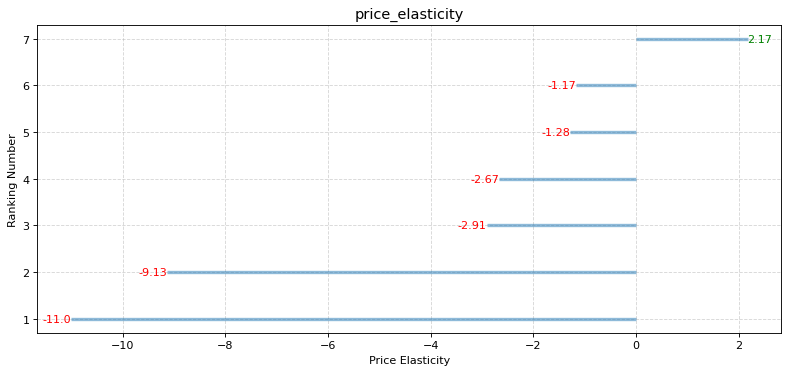

In [41]:
df_elasticity_tv['ranking'] = df_elasticity_tv['price_elasticity'].rank( ascending = True).astype(int)
df_elasticity_tv.sort_values('price_elasticity', ascending =False, inplace = True)
plt.figure(figsize = (12,5), dpi = 80)
plt.hlines(y = df_elasticity_tv['ranking'] , xmin = 0, xmax = df_elasticity_tv['price_elasticity'], alpha = 0.5, linewidth = 3)

 #Add elasticity labels
for x, y, tex in zip(df_elasticity_tv['price_elasticity'], df_elasticity_tv['ranking'], df_elasticity_tv['price_elasticity']):
    plt.text(x, y, round(tex, 2), horizontalalignment='right' if x < 0 else 'left', 
             verticalalignment='center', fontdict={'color':'red' if x < 0 else 'green', 'size':10})
    
# Axis and title
plt.gca().set(ylabel= 'Ranking Number', xlabel= 'Price Elasticity')
plt.yticks(df_elasticity_tv['ranking'])
plt.title('price_elasticity' , fontdict={'size':13})
plt.grid(linestyle='--', alpha=0.5)
plt.show()


In [42]:
df_order_tv = df_elasticity_tv[['ranking', 'name', 'price_elasticity']].sort_values(by='price_elasticity', ascending=False)
df_order_tv

,ranking,name,price_elasticity
4,7,Samsung UN55KS8500 Curved 55-Inch 4K Ultra HD ...,2.168331
2,6,LG Electronics OLED65C6P Curved 65-Inch 4K Ult...,-1.165886
0,5,KS9800-Series 65-Class SUHD Smart Curved LED TV,-1.284299
6,4,Sony 65 Class 4K (2160P) Smart OLED TV (XBR65A...,-2.672437
3,3,"Samsung - 50 Class (49.5"" Diag.) - LED - 1080p...",-2.910986
5,2,Sharp Aquos N7000 65 Class 4K Ultra WiFi Smart...,-9.130677
1,1,LG - 65 Class - LED - SJ8500 Series - 2160p - ...,-10.999933


### laptop, computer

/tmp/ipykernel_1361/848788865.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elasticity_laptop['ranking'] = df_elasticity_laptop['price_elasticity'].rank( ascending = True).astype(int)
/tmp/ipykernel_1361/848788865.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elasticity_laptop.sort_values('price_elasticity', ascending =False, inplace = True)


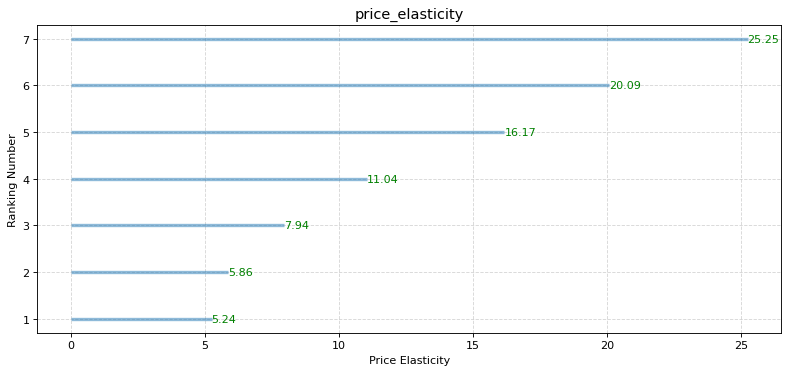

In [43]:
df_elasticity_laptop['ranking'] = df_elasticity_laptop['price_elasticity'].rank( ascending = True).astype(int)
df_elasticity_laptop.sort_values('price_elasticity', ascending =False, inplace = True)
plt.figure(figsize = (12,5), dpi = 80)
plt.hlines(y = df_elasticity_laptop['ranking'] , xmin = 0, xmax = df_elasticity_laptop['price_elasticity'], alpha = 0.5, linewidth = 3)

 #Add elasticity labels
for x, y, tex in zip(df_elasticity_laptop['price_elasticity'], df_elasticity_laptop['ranking'], df_elasticity_laptop['price_elasticity']):
    plt.text(x, y, round(tex, 2), horizontalalignment='right' if x < 0 else 'left', 
             verticalalignment='center', fontdict={'color':'red' if x < 0 else 'green', 'size':10})
    
# Axis and title
plt.gca().set(ylabel= 'Ranking Number', xlabel= 'Price Elasticity')
plt.yticks(df_elasticity_laptop['ranking'])
plt.title('price_elasticity' , fontdict={'size':13})
plt.grid(linestyle='--', alpha=0.5)
plt.show()


In [44]:
df_order_laptop = df_elasticity_laptop[['ranking', 'name', 'price_elasticity']].sort_values(by='price_elasticity', ascending=False)
df_order_laptop

,ranking,name,price_elasticity
0,7,"12 MacBook (Mid 2017, Silver)",25.248992
6,6,Samsung - Notebook 5 15.6 Touch-Screen Laptop ...,20.090646
3,5,Details About Apple Macbook Air 13.3 Laptop (e...,16.174446
4,4,Details About Dell Inspiron I75675650blkpus 15...,11.040806
2,3,Acer 15.6 Chromebook CB5-571-C4G4,7.937966
1,2,ASUS VivoBook Max X541SA 15.6Inch Laptop Intel...,5.856442
5,1,Lenovo - 100S-14IBR 14 Laptop - Intel Celeron ...,5.244056
